In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

In [2]:
print("Downloading data from Hugging Face...")
url_ic = "https://huggingface.co/datasets/mehmetdavut/RubyCraft-3.4-Eval-Logs/resolve/main/ic_before_after.csv"
df = pd.read_csv(url_ic)

base_models_df = (
    df[df["model"].str.endswith("_base")].drop_duplicates(subset=["model"]).copy()
)


def clean_model_name(name):
    name = name.replace("_base", "")
    if "teacher_" in name:
        name = name.replace("teacher_", "Teacher: ")
    return name


base_models_df["clean_model"] = base_models_df["model"].apply(clean_model_name)
base_models_df = base_models_df.sort_values(by="gain_pp", ascending=False)

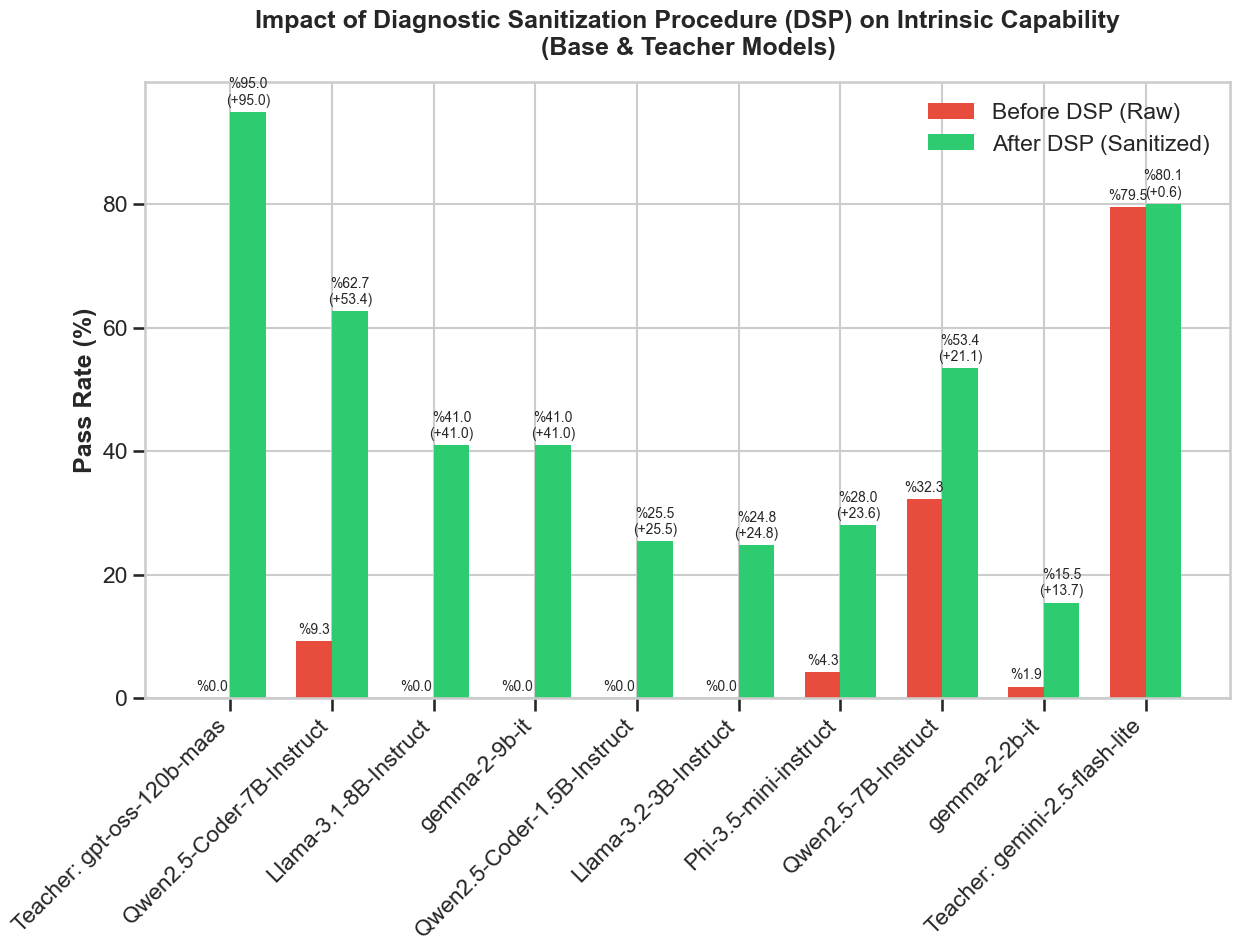

In [10]:
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(base_models_df))
width = 0.35

rects1 = ax.bar(
    x - width / 2,
    base_models_df["before_pct"],
    width,
    label="Before DSP (Raw)",
    color="#e74c3c",
)
rects2 = ax.bar(
    x + width / 2,
    base_models_df["after_pct"],
    width,
    label="After DSP (Sanitized)",
    color="#2ecc71",
)

ax.set_ylabel("Pass Rate (%)", fontweight="bold")
ax.set_title(
    "Impact of Diagnostic Sanitization Procedure (DSP) on Intrinsic Capability\n(Base & Teacher Models)",
    fontweight="bold",
    pad="20",
)
ax.set_xticks(x)
ax.set_xticklabels(base_models_df["clean_model"], rotation=45, ha="right")
ax.legend()


def autolabel(rects, is_after=False):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        if is_after:
            gain = base_models_df.iloc[i]["gain_pp"]
            label_text = f"%{height:.1f}\n(+{gain:.1f})"
        else:
            label_text = f"%{height:.1f}"

        ax.annotate(
            label_text,
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
        )


autolabel(rects1, is_after=False)
autolabel(rects2, is_after=True)

In [11]:
import os

sns.despine()
plt.tight_layout()

os.makedirs("../images", exist_ok=True)
fig.savefig(
    "../images/dsp_impact_base_models.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
    facecolor="white",
)

plt.show()

<Figure size 640x480 with 0 Axes>